# Project 2

## Local Set Up

The dataset that I was using was really large, around 4 GB from (Yelp)[https://business.yelp.com/data/resources/open-dataset/], so I had to do much of the data wrangling locally. 

Here we are initializing the data: 

---

```python
from pathlib import Path
import pandas as pd

# paths
yelp_path = Path(r"C:\Users\ganzs\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset")

business_path = yelp_path / "yelp_academic_dataset_business.json"
review_path = yelp_path / "yelp_academic_dataset_review.json"
user_path = yelp_path / "yelp_academic_dataset_user.json"

businesses = pd.read_json(business_path, lines=True)
users = pd.read_json(user_path, lines=True)
```
---

The database was too big, so I filtered to `Philadelphia` which was the city with the most reviews within the dataset. I also reading the reviews as chunks as I'm applying the filter, because it was taking too long to process if we read everything to memory at once. 
Then I am filtering user's who reviewed more than 20 places, to ensure we have a list of people who actually reviewed. Afterwards I apply a filter on the business dataset to ensure the only businesses remain are those with reviews from our user dataset. 
I then save these into parquet files, thinking it would be small enough to throw on github, however it wasn't, so I had to change course and filter later on in the model. 

---

```python
# get Philadelphia business IDs
philly_ids = set(businesses[businesses['city'] == 'Philadelphia']['business_id'])

# read reviews in chunks and filter Philadelphia only
chunks = []
for chunk in pd.read_json(review_path, lines=True, chunksize=100000):
    filtered = chunk[chunk['business_id'].isin(philly_ids)]
    chunks.append(filtered)

philly_reviews = pd.concat(chunks, ignore_index=True)

# filter users with at least 20 reviews
user_counts = philly_reviews['user_id'].value_counts()
active_users = user_counts[user_counts >= 20].index
philly_reviews = philly_reviews[philly_reviews['user_id'].isin(active_users)].copy()

# keep only businesses that have reviews from these users
active_business_ids = philly_reviews['business_id'].unique()
philly_reviews = philly_reviews[philly_reviews['business_id'].isin(active_business_ids)].copy()
philly_businesses = businesses[businesses['business_id'].isin(active_business_ids)].copy()

# create users dataframe
philly_users = users[users['user_id'].isin(philly_reviews['user_id'])].copy()

# save as Parquet
philly_reviews.to_parquet('philly_reviews.parquet')
philly_businesses.to_parquet('philly_businesses.parquet')
philly_users.to_parquet('philly_users.parquet')

```
---

I then do some summary statistics to see what the data looks like, which made me realize that Yelp has reviews for every type of business. Decided to focus on restaurants, so we filtered the business dataset again for only restaurants, then filtered users that reviewed the remaining restaurant businesses. Then I do another summary statistics to review the data, which informed me on what types of filtering I should do upstream.  

---

```python
# business summary
print("Business Summary\n")
print(philly_businesses[['stars', 'review_count']].describe())
print("\nTop categories:")
print(philly_businesses['categories'].value_counts().head(15))

# split categories into individual tags and count them
all_categories = philly_businesses['categories'].dropna().str.split(', ').explode()
category_counts = all_categories.value_counts()

print(category_counts.head(20))

# filter businesses to only Restaurants
philly_businesses = philly_businesses[
    philly_businesses['categories'].str.contains('Restaurants', na=False)
].copy()

# filter reviews to only these restaurant businesses
philly_reviews = philly_reviews[
    philly_reviews['business_id'].isin(philly_businesses['business_id'])
].copy()

# filter users (keep only those who reviewed these restaurants)
philly_users = philly_users[
    philly_users['user_id'].isin(philly_reviews['user_id'])
].copy()

print("Restaurants only:\n")
print("Reviews:", len(philly_reviews))
print("Users:", len(philly_users))
print("Businesses:", len(philly_businesses))

# review summary
print("Reviews:\n")
print(philly_reviews[['stars', 'useful', 'funny', 'cool']].describe())

# user summary
print("Users:\n")
print(philly_users[['review_count', 'average_stars', 'useful', 'funny', 'cool']].describe())
print(philly_businesses['categories'].head(20))
```
---

After reviewing the data and summaries from the print statements, I realized that I need to remove restaurant and food from the category (although TF-IDF would downweights these categories, I still removed these broad labels as an explicit feature-cleaning step.). We apply the `restaurant` & `food` filter, remove those two from `categories`, rebuild categories as `clean_categories`, and then review the data. We then do another filter across all three datasets to ensure we have users, reviews, and businesses that match. I then create a sample from the user dataset of 500, and do the filter process again. Afterwards I create a dataset that is small enough that I can put on github and use for the recommenders. 

---

```python

df_businesses = philly_businesses.copy()

# split categories into clean lists
df_businesses["category_list"] = (
    df_businesses["categories"]
    .fillna("")
    .str.split(",")
    .apply(lambda cats: [cat.strip() for cat in cats if cat.strip()])
)

# keep only businesses that originally had Restaurants or Food
df_businesses = df_businesses[
    df_businesses["category_list"].apply(
        lambda cats: "Restaurants" in cats or "Food" in cats
    )
].copy()

# remove only the exact labels Restaurants and Food
df_businesses["category_list"] = df_businesses["category_list"].apply(
    lambda cats: [cat for cat in cats if cat not in {"Restaurants", "Food"}]
)

# remove rows where no categories remain
df_businesses = df_businesses[
    df_businesses["category_list"].apply(len) > 0
].copy()

# rebuild clean category string
df_businesses["clean_categories"] = df_businesses["category_list"].apply(", ".join)

# check top remaining categories
remaining_categories = df_businesses["category_list"].explode()

print(remaining_categories.value_counts().head(20))
print("Businesses:", len(df_businesses))

# filter reviews to businesses already selected
df_reviews = philly_reviews[
    philly_reviews["business_id"].isin(df_businesses["business_id"])
].copy()

# keep only users who reviewed those businesses
df_users = philly_users[
    philly_users["user_id"].isin(df_reviews["user_id"])
].copy()

# fandom sample users
sample_users = df_users["user_id"].sample(n=500, random_state=123)

# filter reviews to sampled users
df_reviews = df_reviews[
    df_reviews["user_id"].isin(sample_users)
].copy()

# filter users to sampled users
df_users = df_users[
    df_users["user_id"].isin(sample_users)
].copy()

# filter businesses again to only businesses still reviewed
df_businesses = df_businesses[
    df_businesses["business_id"].isin(df_reviews["business_id"])
].copy()

print("Businesses:", df_businesses["business_id"].nunique())
print("Reviews:", len(df_reviews))
print("Users:", df_users["user_id"].nunique())

# export final filtered/sample data
df_reviews.to_parquet("df_reviews_sample.parquet", index=False)
df_businesses.to_parquet("df_businesses_sample.parquet", index=False)
df_users.to_parquet("df_users_sample.parquet", index=False)

print("Saved:")
print("- df_reviews_sample.parquet")
print("- df_businesses_sample.parquet")
print("- df_users_sample.parquet")

```
---

This code was mostly exploratory preprocessing, if I had known I would need to do so much filtering and matching, I would've created a function for it. I could also had filtered for restaurant & food much earlier, but this was the natural flow of exploring and fixing the data. If I had to reuse this code, I would go back and streamline it. 

## Recommender

### Content-Based Filtering

This is a content-based recommendation model that represents each business using its Yelp categories. For each user, the model builds a profile from businesses they rated highly, then recommends unseen businesses with the highest cosine similarity to that user profile.

Based on the class readings and video, I'm using the TfidVectorizer, which converts the category string (after we separated by delimiter and converted to list) converts it into a vector based on whether that category is a signal or noise based on the rest of the businesses — like earlier I realized I didn't need to filter out restaurants/food from the categories, since it would've ranked them low anyway (haha). We then create a user profile based off businesses they rated high and perform a cosine similarity on the user profile to other businesses and return the top 3 scores, which returns the top three business recommendations.  

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# Create recommendation copies
users_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_users_sample.parquet"
business_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_businesses_sample.parquet"
reviews_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_reviews_sample.parquet"

df_users = pd.read_parquet(users_url)
df_businesses = pd.read_parquet(business_url)
df_reviews = pd.read_parquet(reviews_url)

df_business_rec = df_businesses.copy()
df_review_rec = df_reviews.copy()
df_users_rec = df_users.copy()

# reset index so cosine scores align with rows
df_business_rec = df_business_rec.reset_index(drop=True)

# create item features from cleaned categories
vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(", "),
    token_pattern=None
)

item_features = vectorizer.fit_transform(
    df_business_rec["clean_categories"].fillna("")
)

# build user profiles from businesses rated 4+
high_rated = df_review_rec[df_review_rec["stars"] >= 4]

user_profiles = {}

for user_id in df_users_rec["user_id"]:
    user_business_ids = high_rated.loc[
        high_rated["user_id"] == user_id,
        "business_id"
    ]

    indices = df_business_rec[
        df_business_rec["business_id"].isin(user_business_ids)
    ].index

    if len(indices) > 0:
        user_profiles[user_id] = np.asarray(
            item_features[indices].mean(axis=0)
        ).ravel()


def get_recommendations(user_id, top_n=3):
    if user_id not in user_profiles:
        return "No high-rated businesses found"

    user_vec = user_profiles[user_id]

    sims = cosine_similarity(
        user_vec.reshape(1, -1),
        item_features
    ).flatten()

    reviewed = set(
        df_review_rec.loc[
            df_review_rec["user_id"] == user_id,
            "business_id"
        ]
    )

    candidates = df_business_rec[
        ~df_business_rec["business_id"].isin(reviewed)
    ].copy()

    candidates["score"] = sims[candidates.index]

    return candidates.nlargest(top_n, "score")[
        ["name", "clean_categories", "score"]
    ]

def build_recommendations_df(df_users_rec, recommend_func, top_n=3):
    recommendation_rows = []

    for user_id in df_users_rec["user_id"]:
        recs = recommend_func(user_id, top_n=top_n)

        # Skip users with no recommendations
        if isinstance(recs, str):
            continue

        user_name = df_users_rec.loc[
            df_users_rec["user_id"] == user_id,
            "name"
        ].iloc[0]

        row = {
            "user_id": user_id,
            "name": user_name,
        }

        for i in range(top_n):
            if len(recs) > i:
                row[f"rec_{i+1}_name"] = recs["name"].iloc[i]
                row[f"rec_{i+1}_categories"] = recs["clean_categories"].iloc[i]
                row[f"rec_{i+1}_score"] = recs["score"].iloc[i]
            else:
                row[f"rec_{i+1}_name"] = None
                row[f"rec_{i+1}_categories"] = None
                row[f"rec_{i+1}_score"] = None

        recommendation_rows.append(row)

    return pd.DataFrame(recommendation_rows)


In [2]:
df_recommendations = build_recommendations_df(
    df_users_rec,
    get_recommendations,
    top_n=3
)

df_recommendations.head()

,user_id,name,rec_1_name,rec_1_categories,rec_1_score,rec_2_name,rec_2_categories,rec_2_score,rec_3_name,rec_3_categories,rec_3_score
0,OJorsQjotS1dIv--IVifCA,Cindy,Bumblefish Sushi & More,"Sushi Bars, Specialty Food, Asian Fusion, Seaf...",0.612330,Dream House Asian Bistro,"Sushi Bars, Thai, Asian Fusion, Japanese, Chinese",0.578434,Umai Royal,"Bars, Asian Fusion, Sushi Bars, Chinese, Japan...",0.556895
1,6GHPzEmQNTjC7E3P9VF44w,Rachel,Revolution House,"Pizza, Beer, Wine & Spirits, Nightlife, Americ...",0.713772,The Boilermaker,"Bars, American (New), Nightlife, Beer, Wine & ...",0.655199,In Riva,"Italian, Nightlife, Pizza, Bars, Cocktail Bars...",0.642129
2,Fu8D01UpP5DNnaI7dP9xEw,Ivonne,A La Mousse,"Coffee & Tea, Cafes, Bakeries, Desserts",0.543920,Small Oven Pastry Shop,"Bakeries, Cafes, Desserts",0.533841,Function Coffee Labs,"Bakeries, Breakfast & Brunch, Desserts, Coffee...",0.530361
3,by2k9-QcUwRVIvVOeLU2lg,Sarah,Plenty Cafe,"American (New), Bars, Sandwiches, Nightlife, C...",0.623410,The Gold Standard Cafe,"American (Traditional), American (New), Breakf...",0.597714,Plenty Café,"American (New), Wine Bars, Cafes, Coffee & Tea...",0.585128
4,FoO5vOMb3_nKGmMiDUm8lA,picunte,Revolution House,"Pizza, Beer, Wine & Spirits, Nightlife, Americ...",0.696303,Chestnut 7,"Pizza, American (New), Bars, Burgers, Nightlif...",0.627544,Square 1682,"American (New), Breakfast & Brunch, Bars, Nigh...",0.623902


In [3]:
df_recommendations_sorted = df_recommendations.sort_values(
    by="rec_1_score",
    ascending=False
)

df_recommendations_sorted.head(20)

,user_id,name,rec_1_name,rec_1_categories,rec_1_score,rec_2_name,rec_2_categories,rec_2_score,rec_3_name,rec_3_categories,rec_3_score
385,ewF8tQ01PgwSJbWEdFKS8A,Hannah,Philly Pretzel Factory,"Pretzels, Hot Dogs, Bakeries",1.000000,Philly Pretzel Factory,"Bakeries, Pretzels, Hot Dogs",1.000000,Philly Pretzel Factory,"Bakeries, Pretzels, Hot Dogs",1.000000
379,snQsdEI17lZW8_dj9JYhvg,Dana,Community,"Gastropubs, Pubs, Bars, Nightlife, American (New)",0.873212,Dawson Street Pub,"Nightlife, Pubs, Bars, Gastropubs",0.834644,Tapestry,"Nightlife, Bars, Gastropubs, Pubs",0.834644
239,k-D6ay8pqRE-yXpTL-1eOg,Kayla,Crafty's Tap Room,"Bars, Pubs, American (New), Nightlife, America...",0.835817,Kensington Pub,"Nightlife, Pubs, American (Traditional), Bars,...",0.835817,SOMO SoPhi,"American (Traditional), Nightlife, Bars, Ameri...",0.829263
205,bGjjXHdlIJSvfHEq497OYw,Mama,Barra Restaurant,"Bars, Pizza, Nightlife, Italian",0.829248,Brigantessa,"Italian, Bars, Nightlife, Pizza",0.829248,Santucci's Original Square Pizza,"Italian, Bars, Nightlife, Pizza, Breakfast & B...",0.773935
247,5gQi2KTmdCvJSVkBRLIKvQ,Rich,Fratelly Pizza & Restaurant,"Pizza, Italian, Sandwiches",0.828106,Giovanni's Pizzeria,"Sandwiches, Italian, Pizza",0.828106,Bianca Pizza & Trattoria,"Pizza, Sandwiches, Italian",0.828106
414,3RqYAJfEJDxIpX3xjnCmLw,Tyler,Local Tavern,"Bars, Nightlife, American (New), Italian, Amer...",0.828102,Rocchino's,"American (New), Italian",0.771998,Popi's Italian Restaurant,"Italian, American (New)",0.771998
92,C6OzV9hRKzHZLgr91aPv3A,Meredith,Barra Restaurant,"Bars, Pizza, Nightlife, Italian",0.820916,Brigantessa,"Italian, Bars, Nightlife, Pizza",0.820916,Randi's Restaurant and Bar,"Bars, Nightlife, Italian",0.813745
390,IvqYQzNwEi5KeWcJfZB_gA,Philip,Russet,"French, Italian, American (New)",0.802135,Maison 208,"Nightlife, French, American (New), Bars",0.740190,Baril,"Wine Bars, French, Nightlife, Bars, American (...",0.718058
391,vELZPqIzED2jrx3SxwbiXA,Tasha,Minas Pizza,Pizza,0.795571,Franzone's Pizzeria & Restaurant,Pizza,0.795571,Slices Pizza,Pizza,0.795571
14,BQX9nEi5q8KSqiiMs921Iw,Sara,Tequilas Restaurant,"Bars, Nightlife, Mexican",0.790587,Las Margaritas,"Mexican, Nightlife, Bars",0.790587,Tio Flores,"Bars, Mexican, Nightlife",0.790587


So we can see that Hannah got recommended Philly Pretzel Factory for all three recommendations, which is pretty funny. This happened because each Philly Pretzel Factory location has a different business ID, so the model treats them as separate businesses even though they are part of the same chain.

Based on her reviews, Philly Pretzel Factory was a strong match. The recommender is technically working, but the output is repetitive because it recommends multiple locations with the same business name.

One way to fix this would be to check for repeated business names after generating the recommendation scores. We could sort the recommendations by cosine similarity, then keep only the highest-scoring result for each business name. That way, if a chain appears multiple times, only the best-matching location is returned instead of filling all recommendation slots with the same chain — if cosine score is similar, the choose the first one. 

In [4]:
user_id = "ewF8tQ01PgwSJbWEdFKS8A"

user_top_rated = (
    df_reviews[df_reviews["user_id"].eq(user_id)]
    .merge(
        df_businesses[["business_id", "name", "categories"]],
        on="business_id",
        how="left"
    )
    .sort_values(by="stars", ascending=False)
)

user_top_rated[["business_id", "name", "stars", "categories"]].head(10)

,business_id,name,stars,categories
2,1MPWKk7dBGUUKoys3sBKPA,Philly Pretzel Factory,5,"Pretzels, Hot Dogs, Food, Bakeries, Restaurants"
0,sJ7RwRN1Pd602KDXb6oW0Q,Philly Pretzel Factory,1,"Pretzels, Food, Specialty Food, Hot Dogs, Rest..."
1,JSMvJtdPVGgq9xfc298QVw,New England Pizza,1,"Pizza, Restaurants, Sandwiches"
3,_HjSeGPK9XTL5SWK-zbHOA,Meathead's Deli,1,"Sandwiches, Delis, Restaurants"


We can further debug by reviewing what Hannah has rated. 

And we can see that she that she has only rated 4 other businesses and of those businesses all have 1 (including a Philly Pretzel Factory location), except for the Philly Pretzel Factory with `ID: 1MPWKk7dBGUUKoys3sBKPA`. If you average the stars, Philly Pretzel Factory would be the highest rated business for her profile. So, it makes sense that it was also recommended to her. So there's a lot of things we can do to buff up this recommender.

### Item-Item Collaborative Filtering

I decided to use Item-Item because the dataset would be simpler to compare versus User-User, since users will have different review histories and might not overlap as much when compared to business reviews. I use cosine similarity again, because we are comparing businesses based off how users rated them and then recommending these businesses to similar businesses the user had previously rated.

The current code uses cosine similarity to take the rating matrix (user ratings of businesses) and creates a matrix of each business and their similarity to every other business via the cosine similarity score. Good thing we cut the data to be only 500 users, because it limited the amount of businesses we would have to compare with every other. If we were to do this for millions of businesses and users, we would seek a more scalable model. 

In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# create recommendation copies
users_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_users_sample.parquet"
business_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_businesses_sample.parquet"
reviews_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_reviews_sample.parquet"

df_users = pd.read_parquet(users_url)
df_businesses = pd.read_parquet(business_url)
df_reviews = pd.read_parquet(reviews_url)

df_business_rec = df_businesses.copy()
df_review_rec = df_reviews.copy()
df_users_rec = df_users.copy()

# user-business ratings matrix
rating_matrix = df_review_rec.pivot_table(
    index="user_id",
    columns="business_id",
    values="stars"
).fillna(0)

# item-item similarity matrix
item_similarity = cosine_similarity(rating_matrix.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=rating_matrix.columns,
    columns=rating_matrix.columns
)

def get_item_item_recommendations(user_id, top_n=3):
    if user_id not in rating_matrix.index:
        return "User not found"

    user_ratings = rating_matrix.loc[user_id]
    rated_items = user_ratings[user_ratings > 0]
    rated_business_ids = set(rated_items.index)

    if len(rated_items) == 0:
        return "No rated businesses found"

    scores = {}

    for business_id, rating in rated_items.items():
        similar_items = item_similarity_df[business_id]

        for similar_business_id, similarity in similar_items.items():
            if similar_business_id in rated_business_ids:
                continue

            scores[similar_business_id] = (
                scores.get(similar_business_id, 0)
                + similarity * rating
            )

    # normalize by total rating weight
    total_rating_weight = rated_items.sum()

    for business_id in scores:
        scores[business_id] = scores[business_id] / total_rating_weight

    recs = (
        pd.Series(scores)
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    recs.columns = ["business_id", "score"]

    return recs.merge(
        df_businesses[["business_id", "name", "clean_categories"]],
        on="business_id",
        how="left"
    )

def build_item_item_recommendations_df(df_users_rec, top_n=3):
    recommendation_rows = []

    for user_id in df_users_rec["user_id"]:
        recs = get_item_item_recommendations(user_id, top_n=top_n)

        # skip users with no recommendations
        if isinstance(recs, str):
            continue

        user_name = df_users_rec.loc[
            df_users_rec["user_id"] == user_id,
            "name"
        ].iloc[0]

        row = {
            "user_id": user_id,
            "name": user_name,
        }

        for i in range(top_n):
            if len(recs) > i:
                row[f"rec_{i+1}_business_id"] = recs["business_id"].iloc[i]
                row[f"rec_{i+1}_name"] = recs["name"].iloc[i]
                row[f"rec_{i+1}_categories"] = recs["clean_categories"].iloc[i]
                row[f"rec_{i+1}_score"] = recs["score"].iloc[i]
            else:
                row[f"rec_{i+1}_business_id"] = None
                row[f"rec_{i+1}_name"] = None
                row[f"rec_{i+1}_categories"] = None
                row[f"rec_{i+1}_score"] = None

        recommendation_rows.append(row)

    return pd.DataFrame(recommendation_rows)


With the definition created, we can now use it to get the recommendations for users. Below we will view 3 users. 

In [21]:
df_item_item_recommendations = build_item_item_recommendations_df(
    df_users_rec,
    top_n=3
)

df_item_item_recommendations.head()

,user_id,name,rec_1_business_id,rec_1_name,rec_1_categories,rec_1_score,rec_2_business_id,rec_2_name,rec_2_categories,rec_2_score,rec_3_business_id,rec_3_name,rec_3_categories,rec_3_score
0,OJorsQjotS1dIv--IVifCA,Cindy,9PZxjhTIU7OgPIzuGi89Ew,El Vez,"Lounges, Bars, Nightlife, Breakfast & Brunch, ...",0.139432,V0SHmvYtXqdv8-AsqshV6w,Smokin Bettys,"Nightlife, Bars, American (New), Barbeque",0.129729,OdIBX09glfXNVSyd0RnIeg,Monk's Cafe,"Nightlife, Pubs, Bars, Belgian, Gastropubs",0.117225
1,6GHPzEmQNTjC7E3P9VF44w,Rachel,9PZxjhTIU7OgPIzuGi89Ew,El Vez,"Lounges, Bars, Nightlife, Breakfast & Brunch, ...",0.158888,OdIBX09glfXNVSyd0RnIeg,Monk's Cafe,"Nightlife, Pubs, Bars, Belgian, Gastropubs",0.157560,ctHjyadbDQAtUFfkcAFEHw,Zahav,"Nightlife, Bars, Ethnic Food, Middle Eastern, ...",0.143301
2,Fu8D01UpP5DNnaI7dP9xEw,Ivonne,OdIBX09glfXNVSyd0RnIeg,Monk's Cafe,"Nightlife, Pubs, Bars, Belgian, Gastropubs",0.205087,Yu_QofgDAjn__QsMi5Wudg,The Victoria Freehouse,"Bars, Nightlife, British, Pubs, Breakfast & Br...",0.173348,Iw8uqNPxviwcgxtruAx_LA,Good Dog Bar,"American (Traditional), Bars, Nightlife, Burge...",0.162143
3,by2k9-QcUwRVIvVOeLU2lg,Sarah,PQ15SQ4e9Gpw7KpoYHjlow,Tandoor Authentic Indian Restaurant,"Buffets, Desserts, Vegetarian, Indian, Halal",0.123075,JrDLf5e-awIC0suNlK39Zw,Locust Rendezvous,"Bars, Beer Bar, Salad, Dive Bars, Nightlife",0.113393,HnHAbKQmecWR4VCvub0AdA,Max's Brew Bar,"American (New), Bars, Nightlife, Beer Bar, Ame...",0.112462
4,FoO5vOMb3_nKGmMiDUm8lA,picunte,vEfA3V3pCrnigUFlLJ3gLw,Gleaner's Cafe,"Vegan, Coffee & Tea, Breakfast & Brunch",0.166459,4_W5pstoN1166TGjjPOrMg,Prohibition Taproom,"American (Traditional), Bars, Nightlife, Beer ...",0.156857,HnHAbKQmecWR4VCvub0AdA,Max's Brew Bar,"American (New), Bars, Nightlife, Beer Bar, Ame...",0.152986


In [22]:
df_item_item_recommendations_sorted = df_item_item_recommendations.sort_values(
    by="rec_1_score",
    ascending=False
)

df_item_item_recommendations_sorted.head(10)

,user_id,name,rec_1_business_id,rec_1_name,rec_1_categories,rec_1_score,rec_2_business_id,rec_2_name,rec_2_categories,rec_2_score,rec_3_business_id,rec_3_name,rec_3_categories,rec_3_score
463,zOZR3F-fLi9oP5_PHFlqeQ,David,cbDPotTFcIBONQH6kFFyVA,"Millie's Burgers, Steaks & Shakes","Ice Cream & Frozen Yogurt, Burgers, Pizza, Ame...",0.330999,y9Jpw5Koli_-dGL0S5RI0A,Margherita Pizzeria,Pizza,0.323253,9ZmVhCA2m3yK2mXHDFUlfA,The Pizza Shack,Pizza,0.303123
486,AyPHUQkhEgjoLRzURMHAOA,Becky,oUtWwORqz6XAhDpAxE1IiQ,Won Oriental Restaurant,Chinese,0.236810,6cfNCzL2A0XsmXnjeg0u7w,Cosi,"Coffee & Tea, Pizza, Sandwiches",0.199090,W-esb76USKNAJYhd2xoKnw,Michael's Family Restaurant,American (New),0.199090
480,S1faDnsDyXWbB8kmhdKRsA,Michael,-k1iNvlyQZkZ14Hcqzlk4Q,The Pharmacy,"Shopping, Coffee & Tea, Art Galleries, Cafes, ...",0.222369,O3S4jdMvdf1VCPDoLYtqaA,El Cafeito,"Sandwiches, Coffee & Tea, Cuban, Latin American",0.222369,GrHQITcWhJFOMZ_B2h3oRg,Primo Hoagies South Street,"Sandwiches, Fast Food",0.222369
2,Fu8D01UpP5DNnaI7dP9xEw,Ivonne,OdIBX09glfXNVSyd0RnIeg,Monk's Cafe,"Nightlife, Pubs, Bars, Belgian, Gastropubs",0.205087,Yu_QofgDAjn__QsMi5Wudg,The Victoria Freehouse,"Bars, Nightlife, British, Pubs, Breakfast & Br...",0.173348,Iw8uqNPxviwcgxtruAx_LA,Good Dog Bar,"American (Traditional), Bars, Nightlife, Burge...",0.162143
452,Dh1P-XNtdpc2RQmO3LLZ4Q,Michael,i_5PaxI8DK9EErsHBdwP1A,Tiffin-Etc,Indian,0.204731,hOSLBlM6nkbZ218jwp8AvA,Father & Sons Pasta & Pizza,Pizza,0.204731,0ievJ8EHvr1YjXA1_I-YUg,Shifty's Taco,Tex-Mex,0.204731
66,Ywok1ET26628qFeFA9mnuw,Cecily,I2ISRV7IybkMc3HEYKUE9g,Audrey Claire,"Greek, Mediterranean, Seafood, American (New)",0.200656,TFnGJlA5l_HDdzGDkNTdTA,Smiths Restaurant and Bar,"American (New), Bars, Nightlife, Lounges",0.198717,3FKIev7ZB_KE6XHL9sUJCg,Strangelove's,"Nightlife, Event Planning & Services, Local Fl...",0.187392
487,kynpayfZunwfm8bMR8fRZw,Danielle,edglJsudUEULkxm-rLtQbg,Brigantessa,"Italian, Bars, Nightlife, Pizza",0.199844,trwHwsXOVV-ZmF-MtP98BA,High Street Philadelphia,"Cafes, Pizza, American (New), Breakfast & Brun...",0.195666,7yPzOek7Af2dKWGYKpcHWA,Khmer Kitchen,Cambodian,0.195239
366,b2iK-oXT9onUeODm80oaaA,C,sAEf2gPg15otqUS198Ilrw,Union Jacks Pub Manayunk,"Bars, Pubs, Nightlife",0.197539,2GLQjV1-_KbWDVqa3sVCjA,New Style Pizzeria,"Italian, Pizza, Gluten-Free",0.197539,mI6IKRJ-Q0EsexiCF-C_Eg,Tony Luke's,"Italian, Sandwiches, Cheesesteaks, Local Flavor",0.176684
228,5hh180xTIOfRx_skElgEjQ,Ruchi,gcjziNbsRYMfdcbOuCCufw,Rx Restaurant,"Breakfast & Brunch, American (New)",0.194777,nwk7HiUk0IIYftBDF5yv7w,HomeSlice,Pizza,0.179924,99e7bysta1myyrQogFEWUQ,Dock Street Brewery,"Beer, Wine & Spirits, Breweries, Pizza, Local ...",0.173606
32,1PJ-RjMqXHeymSkLRzuIdA,J,9iBlpXwgBFLVnx6RmHsiCQ,Foods On First,"Sandwiches, Cheesesteaks, Event Planning & Ser...",0.190381,qHe8EQyf72nWO633eGxG7A,Big Ass Slices,"American (Traditional), Pizza",0.181719,AiByKTUdixBd5vWAMyxN5g,Las Vegas Lounge,"Nightlife, Lounges, Bars",0.177055


In [23]:
user_id = "OJorsQjotS1dIv--IVifCA"

get_item_item_recommendations(user_id, top_n=3)[
    ["name", "score", "clean_categories"]
]

,name,score,clean_categories
0,El Vez,0.139432,"Lounges, Bars, Nightlife, Breakfast & Brunch, ..."
1,Smokin Bettys,0.129729,"Nightlife, Bars, American (New), Barbeque"
2,Monk's Cafe,0.117225,"Nightlife, Pubs, Bars, Belgian, Gastropubs"


We can see that user `OJorsQjotS1dIv--IVifCA` has been recommended nightlife and bars for their top 3. We can compare this with the previous recommender to see if this aligns:

In [34]:
user_id = "OJorsQjotS1dIv--IVifCA"

df_recommendations_sorted[df_recommendations_sorted["user_id"].eq(user_id)]

,user_id,name,rec_1_name,rec_1_categories,rec_1_score,rec_2_name,rec_2_categories,rec_2_score,rec_3_name,rec_3_categories,rec_3_score
0,OJorsQjotS1dIv--IVifCA,Cindy,Bumblefish Sushi & More,"Sushi Bars, Specialty Food, Asian Fusion, Seaf...",0.61233,Dream House Asian Bistro,"Sushi Bars, Thai, Asian Fusion, Japanese, Chinese",0.578434,Umai Royal,"Bars, Asian Fusion, Sushi Bars, Chinese, Japan...",0.556895


And it does not! We can also check the user profile for Cindy: 

In [36]:
cindy_reviews = df_reviews[df_reviews["user_id"].eq(user_id)].copy()

print("Review count:", len(cindy_reviews))
print(cindy_reviews[["stars", "useful", "funny", "cool"]].describe())

Review count: 35
           stars     useful      funny       cool
count  35.000000  35.000000  35.000000  35.000000
mean    3.742857   1.200000   0.085714   0.457143
std     0.852086   2.709461   0.284029   0.918530
min     2.000000   0.000000   0.000000   0.000000
25%     3.000000   0.000000   0.000000   0.000000
50%     4.000000   1.000000   0.000000   0.000000
75%     4.000000   1.000000   0.000000   1.000000
max     5.000000  16.000000   1.000000   4.000000


Looks like Cindy rated around 35 restaurants, which is a lot. Let's see how many of them are related to her recommendations: 

In [38]:
cindy_reviews = df_reviews[df_reviews["user_id"].eq(user_id)].copy()

cindy_reviews = cindy_reviews.merge(
    df_businesses[["business_id", "name", "clean_categories", "categories"]],
    on="business_id",
    how="left"
)

cindy_reviews[
    ["business_id", "name", "stars", "clean_categories"]
].sort_values("stars", ascending=False)

,business_id,name,stars,clean_categories
18,poviu-6n3iaRE4gdQz6OYw,Oyster House,5,"Steakhouses, Seafood"
7,jziliEq8Zum-EynD5v-Hvg,Chifa,5,"Peruvian, Chinese, Asian Fusion, Latin American"
6,L4kfcADLCU4T33i7Z0CkuA,Bistro Romano,5,"Bars, Wine Bars, Mediterranean, Italian, Night..."
33,ytynqOUb3hjKeJfRj5Tshw,Reading Terminal Market,5,"Candy Stores, Shopping, Department Stores, Fas..."
32,_tt4nysrN8JpzLLVXL-z5A,Creperie Beau Monde & L'Etage,5,"Breakfast & Brunch, Creperies, French"
25,K3RURR9lIEE4JjOaPt99zg,Sabrina's Café,5,"Vegetarian, Breakfast & Brunch, American (New)..."
17,vUkiYPpbkMXA99WneLSGkQ,Banana Leaf,5,"Singaporean, Malaysian, Sushi Bars, Thai, Asia..."
22,MKsCFQuzmgH2We9hwTQ8gw,South Street Souvlaki,4,Greek
27,ntiIq1FNqduOyyowMFGh5A,Nan Zhou Hand Drawn Noodle House,4,"Specialty Food, Noodles, Ethnic Food, Chinese,..."
2,NVN_23yYJDf_RAinqFICDA,Hot Diggity!,4,"Hot Dogs, Vegetarian"


Interesting, seems like there's a lot of highly rated Asian, Japanese, and Sushi restaurants. 

In [29]:

user_top_rated = (
    df_reviews[df_reviews["user_id"].eq(user_id)]
    .merge(
        df_businesses[["business_id", "name", "categories"]],
        on="business_id",
        how="left"
    )
    .sort_values(by="stars", ascending=False)
)

cindy_rated = user_top_rated[
    (user_top_rated["categories"].str.contains("Sushi|Japanese|Asian", na=False)) &
    (user_top_rated["stars"] >= 4)
][["business_id", "name", "stars", "categories"]]

cindy_rated

,business_id,name,stars,categories
7,jziliEq8Zum-EynD5v-Hvg,Chifa,5,"Peruvian, Chinese, Restaurants, Asian Fusion, ..."
17,vUkiYPpbkMXA99WneLSGkQ,Banana Leaf,5,"Singaporean, Malaysian, Restaurants, Sushi Bar..."
11,XdipvXDdsYt_MDtTaMtXPA,Hikaru Restaurant,4,"Restaurants, Sushi Bars, Japanese"
8,QlC0wdl3pIWnigTR4vDzVQ,5 n 2 Tokyo,4,"Sushi Bars, Restaurants, Japanese, Food"
20,6_T2xzR74JqGCTPefAD8Tw,Morimoto,4,"Japanese, American (Traditional), American (Ne..."


And let's check for the Nightlife|Pub|Lounge categories. 

In [33]:

user_top_rated = (
    df_reviews[df_reviews["user_id"].eq(user_id)]
    .merge(
        df_businesses[["business_id", "name", "categories"]],
        on="business_id",
        how="left"
    )
    .sort_values(by="stars", ascending=False)
)

cindy_rated = user_top_rated[
    (user_top_rated["categories"].str.contains("Nightlife|Pubs|Lounge", na=False)) &
    (user_top_rated["stars"] >= 4)
][["business_id", "name", "stars", "categories"]]

cindy_rated

,business_id,name,stars,categories
6,L4kfcADLCU4T33i7Z0CkuA,Bistro Romano,5,"Restaurants, Bars, Wine Bars, Mediterranean, I..."
14,K9cn-DrPEEXse1s1n-6mMw,Bridget Foy's,4,"Breakfast & Brunch, Nightlife, Bars, American ..."
3,7mpYTDb24SywNMRn3yeakQ,The Twisted Tail,4,"Event Planning & Services, Whiskey Bars, Ameri..."


Pretty difficult to evaluate a comparison between the models, but when we take a look at Cindy we can see that the content-based recommender is doing exactly what it should: recommending more restaurants with similar categories.

Item-item is finding places that people who liked the same restaurants as Cindy also tended to rate similarly. This can surface places that aren't necessarily in the same category but have overlapping user behavior. But, I'm also limiting the amount of data, while I expect both models to gain from having more data to compare, I expect the item-item to have better gains because with the highest score being 0.330999, we can see it kinda struggled compared to the content-based recommender that has high scores even up to 1.0. Although, a 0.33 item-item score can still be meaningful. 

This also shows why recommender systems are difficult to evaluate offline. The models can identify similarity based on categories or rating patterns, but neither model knows whether the user would actually want the recommendation. Real user feedback would be the strongest evaluation signal, such as whether a user clicks, saves, visits, rates, or ignores a recommendation.

This helps explain why companies put so much work into feedback loops. Even with better models, direct user behavior is often the most useful way to judge whether recommendations are actually performing well. For this project, the offline metrics are useful for comparing model behavior, but they should not be treated as a complete measure of recommendation quality.

## Review

We will review the performance of the recommenders. 

In [39]:
# Score columns
score_cols = ["rec_1_score", "rec_2_score", "rec_3_score"]

# Summary stats for recommendation scores
content_score_summary = df_recommendations[score_cols].describe()
item_item_score_summary = df_item_item_recommendations[score_cols].describe()

print("Content-Based Recommendation Score Summary")
display(content_score_summary)

print("Item-Item Collaborative Filtering Score Summary")
display(item_item_score_summary)

Content-Based Recommendation Score Summary


,rec_1_score,rec_2_score,rec_3_score
count,500.000000,500.000000,500.000000
mean,0.633412,0.617100,0.607213
std,0.078738,0.080607,0.081101
min,0.436529,0.428927,0.415732
25%,0.579704,0.560075,0.548467
50%,0.632321,0.616321,0.604264
75%,0.683074,0.666802,0.654967
max,1.000000,1.000000,1.000000


Item-Item Collaborative Filtering Score Summary


,rec_1_score,rec_2_score,rec_3_score
count,500.000000,500.000000,500.000000
mean,0.129566,0.122544,0.119078
std,0.029692,0.028227,0.027119
min,0.000000,0.000000,0.000000
25%,0.110540,0.104955,0.102433
50%,0.130298,0.122133,0.119465
75%,0.146771,0.138647,0.133493
max,0.330999,0.323253,0.303123


The content-based recommender produced higher recommendation scores than the item-item collaborative filtering model. The average first recommendation score for content-based filtering was 0.633, compared with 0.130 for item-item collaborative filtering. The same pattern held for the second and third recommendations.

However, these scores were calculated differently, so they shouldn't be treated as a one-to-one statistical comparison. The content-based model just uses cosine similarity based off TF-IDF while the item-item model used a rating-weighted average similarity score. The reason we used rating-weighted average similarity was to normalize after we took the cosine similarity * rating, to keep it in range of 0-1 and to ensure that users don't just get a high score because they rated a lot of businesses. So while they both use similarity, they use it differently.

The content-based scores make more sense, because the restaurant categories are a clear signal. Like, if someone likes Sushi and Japanese, it will recommend them Sushi and Japanese restaurants. While the item-item model depends on businesses having overlapping users and ratings, which could have been affected by the sampling size. Many businesses do not share enough common reviewers to generate high item-item similarity scores, however it seems it would recommend things way differently than the content-based recommender. I would say, Item-Item might be more interesting and serendipitous, since it will recommend things that a user normally wouldn't expect based off categories alone.

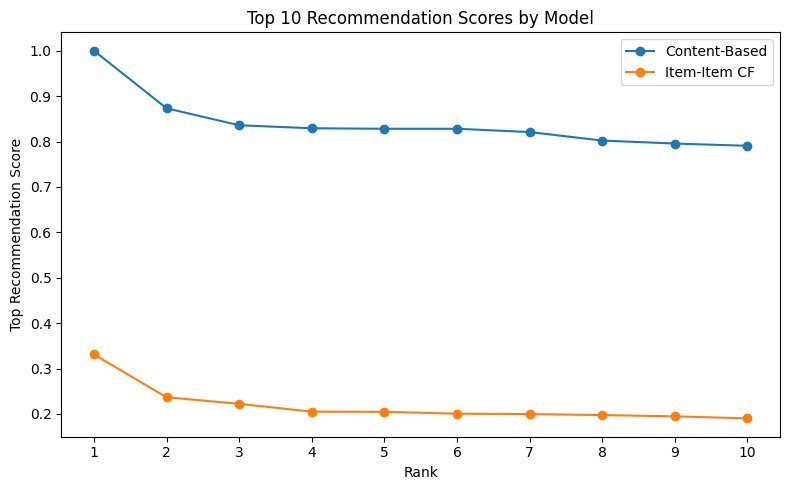

In [ ]:
import matplotlib.pyplot as plt

# Top 10 users by first recommendation score for each model
content_top10 = (
    df_recommendations
    .sort_values("rec_1_score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

item_item_top10 = (
    df_item_item_recommendations
    .sort_values("rec_1_score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Add rank for plotting
content_top10["rank"] = range(1, 11)
item_item_top10["rank"] = range(1, 11)

plt.figure(figsize=(8, 5))

plt.plot(
    content_top10["rank"],
    content_top10["rec_1_score"],
    marker="o",
    label="Content-Based"
)

plt.plot(
    item_item_top10["rank"],
    item_item_top10["rec_1_score"],
    marker="o",
    label="Item-Item CF"
)

plt.title("Top 10 Recommendation Scores by Model")
plt.xlabel("Rank")
plt.ylabel("Top Recommendation Score")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

The assignment called for a graph, so I figured I might as well throw one up. As shown above, the content-based recommender produced higher top recommendation scores than the item-item recommender. However, these scores were calculated differently, so I would not treat this as a perfect one-to-one comparison. The sampling size may have also negatively impacted the item-item recommender, since collaborative filtering depends more on overlapping users and ratings.

## Final Thoughts

This was a fun exercise, but I'm learning that the python route is pretty laborious to create recommenders. Also, the Yelp data needed a lot of plumbing in order to get it in a spot that was useful for the project. The funny thing is that the recommenders are complete and we can use the model to create recommendations for everyone in the dataset. There are also x,y coordinates for the businesses, so we could add location-based filtering to the recommendations later. However, for now it was a good project to prep data and create these recommenders.

As for the recommenders we created and reviewed, I like the content-based recommender because it's easy to understand and worked well with the smaller sampled dataset. The item-item recommender was less straightforward, but I think it could be more interesting with more data because it can recommend businesses based on user behavior instead of categories alone. Overall, this made me appreciate why recommender systems rely so much on user feedback, because offline scores can help compare model behavior, but they do not fully tell us whether a user would actually like the recommendation.